In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "stores")

In [14]:
### CODE FOR WORKSHOP ONLY ####
url_selected_signals = "https://github.com/yszanwar/phase2_qrt_challenge/releases/download/signals/selected_signals.parquet"
selected_signals = pd.read_parquet(url_selected_signals, engine="pyarrow")

In [ ]:
#Loading selected signals
selected_signals = pd.read_parquet(os.path.join(DATA_DIR, "selected_signals.parquet"))

In [15]:
selected_signals.corr()

,ichimoku_conversion,accumulation_distribution_index,average_true_range
ichimoku_conversion,1.000000,0.857898,0.671579
accumulation_distribution_index,0.857898,1.000000,0.420223
average_true_range,0.671579,0.420223,1.000000


In [16]:
# Sharpe for selected signals
sharpe_ratios = selected_signals.mean() / selected_signals.std() * (252 ** 0.5)
sharpe_ratios.sort_values(ascending=False)

average_true_range                 2.363076
ichimoku_conversion                1.676699
accumulation_distribution_index    0.635934
dtype: float64

In [17]:
# Creating equal weight portfolio based on a single signal, with optional sector neutralization
equal_weight_portfolio = selected_signals.sum(axis=1)

Equal Weight Portfolio Sharpe Ratio: 1.68


<Axes: title={'center': 'Equal Weight Portfolio Cumulative Returns'}, xlabel='Date'>

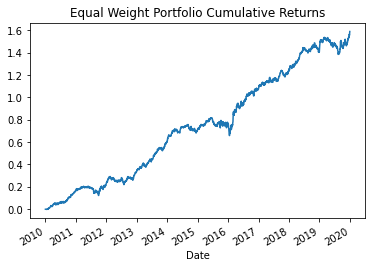

In [18]:
#Equal weight sharpe
print("Equal Weight Portfolio Sharpe Ratio:", np.round(equal_weight_portfolio.mean() / equal_weight_portfolio.std() * (252 ** 0.5), 2))
equal_weight_portfolio.cumsum().plot(title="Equal Weight Portfolio Cumulative Returns")

In [19]:
#Equal Vol Portfolio
vols = selected_signals.std()
inv_vols = 1 / vols
weights = inv_vols / inv_vols.sum()
equal_vol_portfolio = (selected_signals * weights).sum(axis=1)

Equal Vol Portfolio Sharpe Ratio: 1.78


<Axes: title={'center': 'Equal Vol Portfolio Cumulative Returns'}, xlabel='Date'>

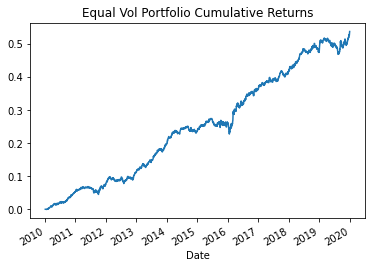

In [20]:
#Equal vol sharpe
print("Equal Vol Portfolio Sharpe Ratio:", np.round(equal_vol_portfolio.mean() / equal_vol_portfolio.std() * (252 ** 0.5), 2))
equal_vol_portfolio.cumsum().plot(title="Equal Vol Portfolio Cumulative Returns")

In [25]:
cov = selected_signals.cov()
inv_cov = np.linalg.inv(cov)
mu = selected_signals.mean()

w = inv_cov @ mu

# project to long-only
w = np.clip(w, 0, None)
mv_weights = w / w.sum()

In [28]:
mv_weights

array([0.47667475, 0.        , 0.52332525])

In [29]:
mv_portfolio = (selected_signals * mv_weights).sum(axis=1)

Mean Variance Portfolio Sharpe Ratio: 2.14


<Axes: title={'center': 'Mean Variance Portfolio Cumulative Returns'}, xlabel='Date'>

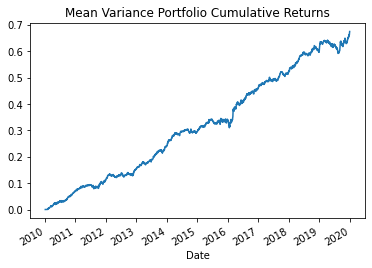

In [30]:
#Mean Variance Optimized Sharpe
print("Mean Variance Portfolio Sharpe Ratio:", np.round(mv_portfolio.mean() / mv_portfolio.std() * (252 ** 0.5), 2))
mv_portfolio.cumsum().plot(title="Mean Variance Portfolio Cumulative Returns")